# HF TDOA Analysis - Figures 13 & 14

This notebook uses the `hf_tdoa_lib` library to analyze HF TDOA measurements and generate Figures 13 and 14.

In [2]:
import os
import datetime
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

import pandas as pd

import hf_tdoa_lib as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [3]:
base_dir   = 'data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [4]:
wavlist

['data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1413UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1423UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1433UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1443UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1454UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1503UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1513UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240408.1523UTC-TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m.wav',
 'data/TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-0318km-40m/20240

In [5]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)

## Find TDOAs

In [6]:
debug_TDOAs = False

tdoa_dct = {}

### 1F2-2F2
tdoa_dct['1F2-2F2']  = dct = {}
dct['filter_limts']  = [10,50]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,11,20] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (142,36.1)       # (slope,intercept) for layer height model
dct['linestyle']     = '--'
dct['linewidth']     = 3
dct['color']         = 'tab:green'
dct['marker']        = 'o'

# ### 1F2-1E
# tdoa_dct['1F2-1E']   = dct = {}
# dct['filter_limts']  = [2.5,30]        # Bandpass filter limits [Hz]
# dct['search_limits'] = [-0.1,0.1,5,12] # (start_offset, end_offset, min_freq, max_freq)
# dct['model_coeffs']  = (181.8,135.5)   # (slope,intercept) for layer height model
# dct['linestyle']     = '-.'
# dct['linewidth']     = 1.5
# dct['color']         = 'tab:blue'
# dct['marker']        = '*'

# ### 2F2-1E
# tdoa_dct['2F2-1E'] = dct = {}
# dct['filter_limts']  = [20,30]          # Bandpass filter limits [Hz]
# dct['search_limits'] = [-0.1,0.1,22,30] # (start_offset, end_offset, min_freq, max_freq)
# dct['model_coeffs']  = (79.4,85.6)      # (slope,intercept) for layer height model
# dct['linestyle']     = ':'
# dct['linewidth']     = 2.5
# dct['color']         = 'tab:orange'
# dct['marker']        = '^'

for set_name, params in tdoa_dct.items():
    filter_limts  = params['filter_limts']
    search_limits = params['search_limits']
    chirps        = tdoa.find_TDOAs(chirps, search_limits, filter_limts, set_name=set_name,
                                   plot_fft=debug_TDOAs, only_one=debug_TDOAs)

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/fig_11_12/hf_tdoa_lib.py:489: RuntimeWarning: Mean of empty slice
  mean_beats.append(np.nanmean(beat_arr))


## Figure 13 - TDOA Measurements

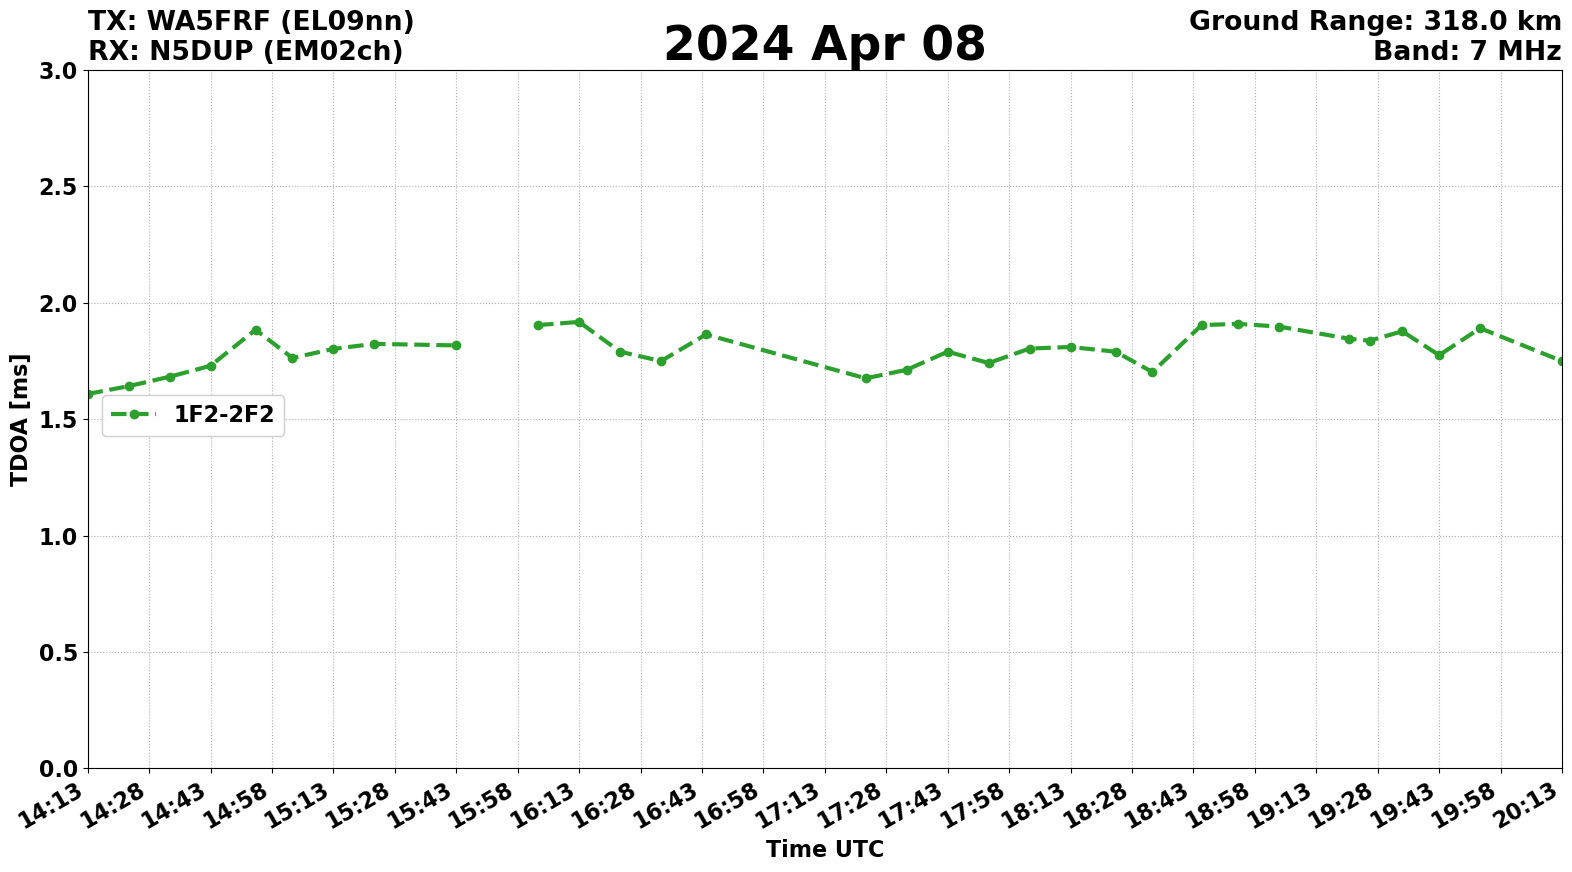

In [7]:
tdoa.plot_TDOAs(chirps, tdoa_dct)

## Figure 14 - Layer Heights Comparison with Ionosonde

In [8]:
# Ionosonde hmF2 data
IonosondeLayer_Height = [263, 258.2, 253.2, 246.7, 249.7, 254.8, 249.8, 253, 252, 265.7, 275.6, 279.7, 275.5, 277.7, 279.2, 270.8, 263.5, 265.8, 283.6, 286, 298.1, 295.5, 297.2, 292.7, 295.6, 299.7, 296.4, 293, 288.3, 284.5, 280.7, 285, 298.6, 287.8, 286.5, 279.3, 283.8, 296.8, 289.1, 300.3, 291.9, 288.9, 300.4, 295.8, 289.4, 292, 300.7, 290.9, 307.4, 304.7, 292.8, 302.3, 313.6, 308.7, 300, 291.7, 302.4, 303.7, 301, 306.2, 298.3, 284.9, 291.4, 293.8, 292.5, 302.4, 286.6, 285.9, 276.5, 288, 286.5, 278.9, 275.9, 270.6, 280.7, 276.1, 273.1, 275.7, 279.2, 299.5, 290.9, 285.8, 278.9, 281, 288.8, 279.9, 281, 277.4, 277, 271.5, 276.9]
Ionosonde_times = [
    "14:00:05", "14:05:05", "14:10:05", "14:15:05", "14:20:05", "14:25:05", "14:30:05", "14:35:05", "14:40:05", "14:45:05",
    "14:50:05", "14:55:05", "15:00:05", "15:05:05", "15:10:05", "15:15:05", "15:20:05", "15:25:05", "15:30:05", "15:35:05",
    "15:40:05", "15:45:05", "15:50:05", "15:55:05", "16:00:05", "16:05:05", "16:10:05", "16:15:05", "16:20:05", "16:25:05",
    "16:30:05", "16:35:05", "16:40:05", "16:45:05", "16:50:05", "16:55:05", "17:00:05", "17:05:05", "17:10:05", "17:15:05",
    "17:20:05", "17:25:05", "17:30:05", "17:35:05", "17:40:05", "17:45:05", "17:50:05", "17:55:05", "18:00:05", "18:05:05",
    "18:10:05", "18:15:05", "18:20:05", "18:25:05", "18:30:05", "18:35:05", "18:40:05", "18:45:05", "18:50:05", "18:55:05",
    "19:00:05", "19:05:05", "19:10:05", "19:15:05", "19:20:05", "19:25:05", "19:30:05", "19:35:05", "19:40:05", "19:45:05",
    "19:50:05", "19:55:05", "20:00:05", "20:05:05", "20:10:05", "20:15:05", "20:20:05", "20:25:05", "20:30:05", "20:35:05",
    "20:40:05", "20:45:05", "20:50:05", "20:55:05", "21:00:05", "21:05:05", "21:10:05", "21:15:05", "21:20:05", "21:25:05",
    "21:30:05"
]
date_str = "2024-04-08"
Ionosonde_datetimes = [datetime.datetime.strptime(date_str + " " + time_str, "%Y-%m-%d %H:%M:%S") for time_str in Ionosonde_times]

In [9]:
# Ionosonde hmE data
IonosondeLayer_HeighthmE = [101.2, 101, 110, 97.2, 97.4, 97.1, 89.6, 90.3, 110, 98.7, 110, 91.5, 88.5, 90, 102.3, 97.7, 89.8, 110, 100, 90.8, 93.8, 93.1, 110, 107.2, 110, 119.1, 97.2, 97, 101.5, 100.8, 108.4, 110, 110, 110, 101.1, 110, 103.4, 96.5, 110, 120.5, 110, 110, 101.2, 111, 110, 110, 110, 110, 97.5, 90.3, 97.8, 110, 105.3, 113.8, 119.6, 110, 110, 116.1, 108.6, 110, 110, 114.5, 100.9, 99.4, 93.7, 110, 120.2, 85.8, 93.4, 89.6, 110, 107.3, 110, 110, 101.9, 123.3, 93.6, 110, 99.1, 110, 105.3, 95.5, 118.5, 95.6, 110, 110, 108.6, 101.6, 93.3, 102.5, 110]
Ionosonde_timeshmE = [
    "14:00:05", "14:05:05", "14:10:05", "14:15:05", "14:20:05", "14:25:05", "14:30:05", "14:35:05", "14:40:05", "14:45:05",
    "14:50:05", "14:55:05", "15:00:05", "15:05:05", "15:10:05", "15:15:05", "15:20:05", "15:25:05", "15:30:05", "15:35:05",
    "15:40:05", "15:45:05", "15:50:05", "15:55:05", "16:00:05", "16:05:05", "16:10:05", "16:15:05", "16:20:05", "16:25:05",
    "16:30:05", "16:35:05", "16:40:05", "16:45:05", "16:50:05", "16:55:05", "17:00:05", "17:05:05", "17:10:05", "17:15:05",
    "17:20:05", "17:25:05", "17:30:05", "17:35:05", "17:40:05", "17:45:05", "17:50:05", "17:55:05", "18:00:05", "18:05:05",
    "18:10:05", "18:15:05", "18:20:05", "18:25:05", "18:30:05", "18:35:05", "18:40:05", "18:45:05", "18:50:05", "18:55:05",
    "19:00:05", "19:05:05", "19:10:05", "19:15:05", "19:20:05", "19:25:05", "19:30:05", "19:35:05", "19:40:05", "19:45:05",
    "19:50:05", "19:55:05", "20:00:05", "20:05:05", "20:10:05", "20:15:05", "20:20:05", "20:25:05", "20:30:05", "20:35:05",
    "20:40:05", "20:45:05", "20:50:05", "20:55:05", "21:00:05", "21:05:05", "21:10:05", "21:15:05", "21:20:05", "21:25:05",
    "21:30:05"
]
date_str = "2024-04-08"
Ionosonde_datetimeshmE = [datetime.datetime.strptime(date_str + " " + time_str, "%Y-%m-%d %H:%M:%S") for time_str in Ionosonde_timeshmE]

In [14]:
df = pd.DataFrame({'hmE': IonosondeLayer_HeighthmE, 'hmF2': IonosondeLayer_Height},index=Ionosonde_datetimes)

fname = os.path.join('data', 'CSVs','2024-04-08_Austin_TX_Ionosonde_hmE_hmF2.csv')
df.to_csv(fname, index_label='UTC')

In [11]:
def plot_hmf2(chirps, tdoa_dct, ionosonde_times, ionosonde_heights,
              ionosonde_times_hme=None, ionosonde_heights_hme=None, ylim=(75,450)):
    """
    Plots layer heights derived from TDOAs and compares with ionosonde measurements.

    Arguments:
    chirps : pd.DataFrame
        DataFrame containing chirp data and TDOA measurements.
    tdoa_dct : dict
        Dictionary containing TDOA set configurations with model coefficients and plotting parameters.
    ionosonde_times : list
        List of datetime objects for ionosonde hmF2 measurements.
    ionosonde_heights : list
        List of hmF2 layer heights from ionosonde.
    ionosonde_times_hme : list, optional
        List of datetime objects for ionosonde hmE measurements.
    ionosonde_heights_hme : list, optional
        List of hmE layer heights from ionosonde.
    ylim : tuple, optional
        Y-axis limits for the plot. Default is (75, 450).
    """
    times = chirps['utc']

    fig   = plt.figure(figsize=(16, 9))
    ax    = fig.add_subplot(1, 1, 1)

    for set_name, params in tdoa_dct.items():
        TDOAs = chirps[f'{set_name}_mean']
        coefs = params['model_coeffs']
        layer_heights = (coefs[0] * TDOAs) + coefs[1]

        line, = ax.plot(times, layer_heights,
                label='Chirp Method: ' + set_name,
                marker = params.get('marker', 'o'),
                linestyle=params.get('linestyle'),
                linewidth=params.get('linewidth'),
                color=params.get('color'))


    prn_df = pd.read_csv('layer_heights_N5DUP_40m_PRN_method.csv', index_col=0, parse_dates=True)
    prn_utc = prn_df.index
    prn_layer_heights = prn_df['layer_heights']
    ax.plot(prn_utc, prn_layer_heights, color='red',
            label="PRN Method", linewidth=2)

    ax.set_ylim(ylim)

    myFmt = mdates.DateFormatter('%H:%M')
    ax.xaxis.set_major_formatter(myFmt)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
    ax.set_ylabel('Layer Height [km]')
    ax.set_xlabel('Time UTC')

    ax.plot(ionosonde_times, ionosonde_heights, color='purple',
            label="Austin Ionosonde hmf2", linewidth=2)

    if ionosonde_times_hme is not None and ionosonde_heights_hme is not None:
        ax.plot(ionosonde_times_hme, ionosonde_heights_hme, color='brown',
                label="Austin Ionosonde hmE", linewidth=2)

    ax.legend()
    fig.autofmt_xdate()

    pfx = chirps.attrs.get('pfx', '')
    tdoa.title_from_pfx(ax, pfx, times[0])

    plt.tight_layout()
    plt.show()

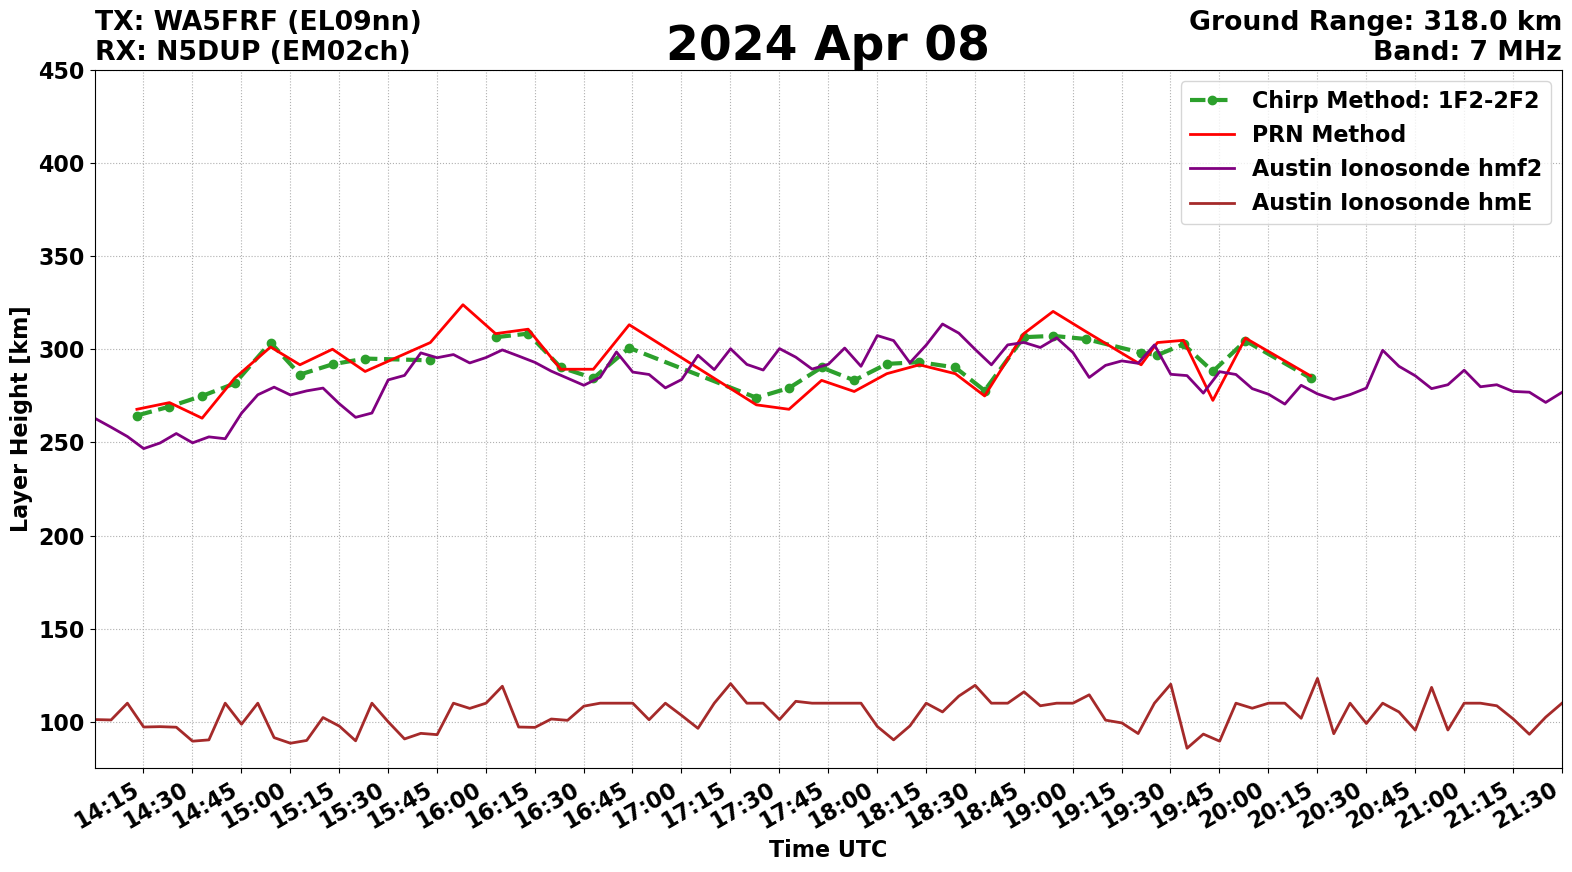

In [12]:
plot_hmf2(chirps, tdoa_dct, 
               ionosonde_times=Ionosonde_datetimes, 
               ionosonde_heights=IonosondeLayer_Height,
               ionosonde_times_hme=Ionosonde_datetimeshmE,
               ionosonde_heights_hme=IonosondeLayer_HeighthmE)

In [13]:
df

,hmE,hmF2
2024-04-08 14:00:05,101.2,263.0
2024-04-08 14:05:05,101.0,258.2
2024-04-08 14:10:05,110.0,253.2
2024-04-08 14:15:05,97.2,246.7
2024-04-08 14:20:05,97.4,249.7
...,...,...
2024-04-08 21:10:05,108.6,281.0
2024-04-08 21:15:05,101.6,277.4
2024-04-08 21:20:05,93.3,277.0
2024-04-08 21:25:05,102.5,271.5
